In [440]:
import pandas as pd
from pathlib import Path
import plotly.express as px
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [441]:
# LOADING THE DATAFRAME

data_file = Path('..') / '01_data' / 'train.csv'
df_raw = pd.read_csv(data_file, sep=',')


In [442]:
df = df_raw.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [443]:
# DATA SET PREVIEW

pd.set_option('display.max_columns', None)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [444]:
# CONVERT OBJECT TO STRING

columns_object = df.select_dtypes(include='object')
columns_str = columns_object.convert_dtypes(convert_string=True)

df[columns_object.columns] = columns_str

In [445]:
# STRING NORMALIZATION

df.columns = df.columns.str.upper()
columns_str = df.select_dtypes(include='string')

for col in columns_str.columns:
    df[col] = df[col].str.upper()

In [446]:
null_values = df.isnull().mean()*100
null_values[null_values > 0].sort_values(ascending=False).round(2)

POOLQC          99.52
MISCFEATURE     96.30
ALLEY           93.77
FENCE           80.75
MASVNRTYPE      59.73
FIREPLACEQU     47.26
LOTFRONTAGE     17.74
GARAGETYPE       5.55
GARAGEYRBLT      5.55
GARAGEFINISH     5.55
GARAGEQUAL       5.55
GARAGECOND       5.55
BSMTEXPOSURE     2.60
BSMTFINTYPE2     2.60
BSMTQUAL         2.53
BSMTCOND         2.53
BSMTFINTYPE1     2.53
MASVNRAREA       0.55
ELECTRICAL       0.07
dtype: float64

In [447]:
high_missing_cols = null_values[null_values > 40]
medium_missing_cols = null_values[(null_values < 40) & (null_values > 10)]
low_missing_cols = null_values[null_values < 10]

df = df.drop(high_missing_cols.index, axis=1)
df = df.dropna(subset=low_missing_cols.index)
df[medium_missing_cols.index] = df[medium_missing_cols.index].fillna(df[medium_missing_cols.index].mean())

In [448]:
columns_qual_nom = [
    'MSSUBCLASS',
    'MSZONING',
    'STREET',
    'LANDCONTOUR',
    'UTILITIES',
    'LOTCONFIG',
    'NEIGHBORHOOD',
    'CONDITION1',
    'CONDITION2',
    'BLDGTYPE',
    'HOUSESTYLE',
    'ROOFSTYLE',
    'ROOFMATL',
    'EXTERIOR1ST',
    'EXTERIOR2ND',
    'FOUNDATION',
    'HEATING',
    'CENTRALAIR',
    'ELECTRICAL',
    'GARAGETYPE',
    'GARAGEFINISH',
    'PAVEDDRIVE',
    'SALETYPE',
    'SALECONDITION',
]

columns_qual_ord = [
    'LOTSHAPE',
    'OVERALLQUAL',
    'OVERALLCOND',
    'EXTERQUAL',
    'EXTERCOND',
    'BSMTQUAL',
    'BSMTCOND',
    'BSMTEXPOSURE',
    'BSMTFINTYPE1',
    'BSMTFINTYPE2',
    'HEATINGQC',
    'KITCHENQUAL',
    'FUNCTIONAL',
    'GARAGEQUAL',
    'GARAGECOND',
    'LANDSLOPE',
]

columns_quan_disc = [
    'YEARBUILT',
    'YEARREMODADD',
    'BSMTFULLBATH',
    'BSMTHALFBATH',
    'FULLBATH',
    'HALFBATH',
    'BEDROOMABVGR',
    'KITCHENABVGR',
    'TOTRMSABVGRD',
    'FIREPLACES',
    'GARAGEYRBLT',
    'GARAGECARS',
    'MOSOLD',
    'YRSOLD',
]

columns_quan_cont = [
    'LOTFRONTAGE',
    'LOTAREA',
    'MASVNRAREA',
    'BSMTFINSF1',
    'BSMTFINSF2',
    'BSMTUNFSF',
    'TOTALBSMTSF',
    '1STFLRSF',
    '2NDFLRSF',
    'LOWQUALFINSF',
    'GRLIVAREA',
    'GARAGEAREA',
    'WOODDECKSF',
    'OPENPORCHSF',
    'ENCLOSEDPORCH',
    '3SSNPORCH',
    'SCREENPORCH',
    'POOLAREA',
    'MISCVAL',
]

target = ['SALEPRICE']


In [449]:
df.head()

,ID,MSSUBCLASS,MSZONING,LOTFRONTAGE,LOTAREA,STREET,LOTSHAPE,LANDCONTOUR,UTILITIES,LOTCONFIG,LANDSLOPE,NEIGHBORHOOD,CONDITION1,CONDITION2,BLDGTYPE,HOUSESTYLE,OVERALLQUAL,OVERALLCOND,YEARBUILT,YEARREMODADD,ROOFSTYLE,ROOFMATL,EXTERIOR1ST,EXTERIOR2ND,MASVNRAREA,EXTERQUAL,EXTERCOND,FOUNDATION,BSMTQUAL,BSMTCOND,BSMTEXPOSURE,BSMTFINTYPE1,BSMTFINSF1,BSMTFINTYPE2,BSMTFINSF2,BSMTUNFSF,TOTALBSMTSF,HEATING,HEATINGQC,CENTRALAIR,ELECTRICAL,1STFLRSF,2NDFLRSF,LOWQUALFINSF,GRLIVAREA,BSMTFULLBATH,BSMTHALFBATH,FULLBATH,HALFBATH,BEDROOMABVGR,KITCHENABVGR,KITCHENQUAL,TOTRMSABVGRD,FUNCTIONAL,FIREPLACES,GARAGETYPE,GARAGEYRBLT,GARAGEFINISH,GARAGECARS,GARAGEAREA,GARAGEQUAL,GARAGECOND,PAVEDDRIVE,WOODDECKSF,OPENPORCHSF,ENCLOSEDPORCH,3SSNPORCH,SCREENPORCH,POOLAREA,MISCVAL,MOSOLD,YRSOLD,SALETYPE,SALECONDITION,SALEPRICE
0,1,60,RL,65.0,8450,PAVE,REG,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2003,2003,GABLE,COMPSHG,VINYLSD,VINYLSD,196.0,GD,TA,PCONC,GD,TA,NO,GLQ,706,UNF,0,150,856,GASA,EX,Y,SBRKR,856,854,0,1710,1,0,2,1,3,1,GD,8,TYP,0,ATTCHD,2003.0,RFN,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,NORMAL,208500
1,2,20,RL,80.0,9600,PAVE,REG,LVL,ALLPUB,FR2,GTL,VEENKER,FEEDR,NORM,1FAM,1STORY,6,8,1976,1976,GABLE,COMPSHG,METALSD,METALSD,0.0,TA,TA,CBLOCK,GD,TA,GD,ALQ,978,UNF,0,284,1262,GASA,EX,Y,SBRKR,1262,0,0,1262,0,1,2,0,3,1,TA,6,TYP,1,ATTCHD,1976.0,RFN,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,NORMAL,181500
2,3,60,RL,68.0,11250,PAVE,IR1,LVL,ALLPUB,INSIDE,GTL,COLLGCR,NORM,NORM,1FAM,2STORY,7,5,2001,2002,GABLE,COMPSHG,VINYLSD,VINYLSD,162.0,GD,TA,PCONC,GD,TA,MN,GLQ,486,UNF,0,434,920,GASA,EX,Y,SBRKR,920,866,0,1786,1,0,2,1,3,1,GD,6,TYP,1,ATTCHD,2001.0,RFN,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,NORMAL,223500
3,4,70,RL,60.0,9550,PAVE,IR1,LVL,ALLPUB,CORNER,GTL,CRAWFOR,NORM,NORM,1FAM,2STORY,7,5,1915,1970,GABLE,COMPSHG,WD SDNG,WD SHNG,0.0,TA,TA,BRKTIL,TA,GD,NO,ALQ,216,UNF,0,540,756,GASA,GD,Y,SBRKR,961,756,0,1717,1,0,1,0,3,1,GD,7,TYP,1,DETCHD,1998.0,UNF,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,ABNORML,140000
4,5,60,RL,84.0,14260,PAVE,IR1,LVL,ALLPUB,FR2,GTL,NORIDGE,NORM,NORM,1FAM,2STORY,8,5,2000,2000,GABLE,COMPSHG,VINYLSD,VINYLSD,350.0,GD,TA,PCONC,GD,TA,AV,GLQ,655,UNF,0,490,1145,GASA,EX,Y,SBRKR,1145,1053,0,2198,1,0,2,1,4,1,GD,9,TYP,1,ATTCHD,2000.0,RFN,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,NORMAL,250000


## Treatment of Qualitative Nominal variables

In [450]:
# FIRST ANALYSIS

df_clean_qual_nom = df.copy()

for col in columns_qual_nom:
    print(df_clean_qual_nom[col].value_counts())
    print()

MSSUBCLASS
20     502
60     294
50     129
120     86
160     61
80      57
70      57
30      51
90      28
190     21
85      19
75      14
45       9
180      6
40       4
Name: count, dtype: int64

MSZONING
RL         1066
RM          191
FV           62
RH           11
C (ALL)       8
Name: count, dtype: Int64

STREET
PAVE    1333
GRVL       5
Name: count, dtype: Int64

LANDCONTOUR
LVL    1206
BNK      52
HLS      48
LOW      32
Name: count, dtype: Int64

UTILITIES
ALLPUB    1337
NOSEWA       1
Name: count, dtype: Int64

LOTCONFIG
INSIDE     957
CORNER     244
CULDSAC     90
FR2         43
FR3          4
Name: count, dtype: Int64

NEIGHBORHOOD
NAMES      209
COLLGCR    146
OLDTOWN    100
SOMERST     83
GILBERT     77
NRIDGHT     75
NWAMES      73
EDWARDS     70
SAWYER      69
SAWYERW     53
CRAWFOR     50
BRKSIDE     47
MITCHEL     42
NORIDGE     41
TIMBER      37
IDOTRR      29
CLEARCR     26
STONEBR     25
SWISU       20
BLMNGTN     17
BRDALE      15
MEADOWV     12
VEENKER     

In [451]:
columns_to_drop = [
    'MSSUBCLASS',
    'STREET',
    'LANDCONTOUR',
    'NEIGHBORHOOD',
    'UTILITIES',
    'CONDITION2',
    'ROOFMATL',
    'EXTERIOR2ND',
    'HEATING',
    'CENTRALAIR',
    'ELECTRICAL',
    'PAVEDDRIVE',
]

df_clean_qual_nom = df_clean_qual_nom.drop(columns=columns_to_drop, axis=1)

# MSZONING
df_clean_qual_nom['MSZONING'] = df_clean_qual_nom[df_clean_qual_nom['MSZONING'] != 'C (ALL)']['MSZONING']

# LOTCONFIG
mapping_lotconfig = {
    'INSIDE': 'SINGLE_FRONTAGE',
    'CULDSAC': 'SINGLE_FRONTAGE',
    'CORNER': 'MULTIPLE_FRONTAGE',
    'FR2': 'MULTIPLE_FRONTAGE',
    'FR3': 'MULTIPLE_FRONTAGE',
}
df_clean_qual_nom['LOTCONFIG'] = df_clean_qual_nom['LOTCONFIG'].replace(
    mapping_lotconfig
)

# CONDITION1 - NOISE
df_clean_qual_nom = df_clean_qual_nom.rename(columns={'CONDITION1': 'NOISE'})

mapping_noise = {
    'ARTERY': 'HIGH',
    'FEEDR': 'HIGH',
    'RRNN': 'HIGH',
    'RRAN': 'HIGH',
    'RRNE': 'HIGH',
    'RRAE': 'HIGH',
    'POSN': 'LOW',
    'POSA': 'LOW',
    'NORM': 'NORMAL',
}
df_clean_qual_nom['NOISE'] = df_clean_qual_nom['NOISE'].replace(mapping_noise)

# BLDGTYPE
mapping_bldgtype = {
    'TWNHSE': 'TOWNHOUSE',
    'TWNHSI': 'TOWNHOUSE',
    'TWNHS': 'TOWNHOUSE',
    'DUPLEX': 'MULTI-FAMILY',
    '2FMCON': 'MULTI-FAMILY',
}
df_clean_qual_nom['BLDGTYPE'] = df_clean_qual_nom['BLDGTYPE'].replace(mapping_bldgtype)

# HOUSESTYLE
mapping_housestyle = {
    '1STORY': '1STORY',
    '2STORY': '2STORY',
    '1.5FIN': '1.5STORY',
    '1.5UNF': '1.5STORY',
    '2.5FIN': '2STORY',
    '2.5UNF': '2STORY',
    'SLVL': 'SPLIT',
    'SFOYER': 'SPLIT',
}
df_clean_qual_nom['HOUSESTYLE'] = df_clean_qual_nom['HOUSESTYLE'].replace(
    mapping_housestyle
)

# ROOFSTYLE
mapping_roofstyle = {
    'GABLE': 'GABLE',
    'HIP': 'NON-GABLE',
    'FLAT': 'NON-GABLE',
    'GAMBREL': 'NON-GABLE',
    'MANSARD': 'NON-GABLE',
    'SHED': 'NON-GABLE',
}
df_clean_qual_nom['ROOFSTYLE'] = df_clean_qual_nom['ROOFSTYLE'].replace(
    mapping_roofstyle
)

# EXTERIOR1ST
mapping_exterior1st = {
    'VINYLSD': 'VINYLSD',
    'HDBOARD': 'HDBOARD',
    'METALSD': 'METALSD',
    'WD SDNG': 'WD SDNG',
    'PLYWOOD': 'PLYWOOD',
    'CEMNTBD': 'OTHER',
    'BRKFACE': 'OTHER',
    'STUCCO': 'OTHER',
    'WDSHING': 'OTHER',
    'ASBSHNG': 'OTHER',
    'STONE': 'OTHER',
    'BRKCOMM': 'OTHER',
    'IMSTUCC': 'OTHER',
    'CBLOCK': 'OTHER',
}
df_clean_qual_nom['EXTERIOR1ST'] = df_clean_qual_nom['EXTERIOR1ST'].replace(
    mapping_exterior1st
)

# FOUNDATION
df_clean_qual_nom = df_clean_qual_nom[
    df_clean_qual_nom['FOUNDATION'].isin(['PCONC', 'CBLOCK', 'BRKTIL'])
]

# GARAGETYPE
mapping_garagetype = {
    'ATTCHD': 'ATTCHD',
    'DETCHD': 'DETCHD',
    'BUILTIN': 'OTHER',
    'BASMENT': 'OTHER',
    'CARPORT': 'OTHER',
    '2TYPES': 'OTHER',
}
df_clean_qual_nom['GARAGETYPE'] = df_clean_qual_nom['GARAGETYPE'].replace(
    mapping_garagetype
)

# SALETYPE
mapping_saletype = {
    'WD': 'WD',
    'NEW': 'NEW',
    'COD': 'COD',
    'CONLD': 'CON',
    'CONLI': 'CON',
    'CWD': 'WD',
    'CONLW': 'CON',
    'OTH': 'OTH',
}
df_clean_qual_nom['SALETYPE'] = df_clean_qual_nom['SALETYPE'].replace(mapping_saletype)
df_clean_qual_nom = df_clean_qual_nom[df_clean_qual_nom['SALETYPE'] != 'OTH']

# SALECONDITION
df_clean_qual_nom = df_clean_qual_nom[
    df_clean_qual_nom['SALECONDITION'].isin(['NORMAL', 'PARTIAL', 'ABNORML'])
]
df_clean_qual_nom['SALECONDITION'] = df_clean_qual_nom['SALECONDITION'].replace(
    'ABNORML', 'ABNORMAL'
)

# FILTERING LIST
columns_qual_nom = list(
    (set(columns_qual_nom) - set(columns_to_drop)) - {'CONDITION1'} | {'NOISE'}
)


In [452]:
df_clean_qual_nom[columns_qual_nom].head()

,FOUNDATION,EXTERIOR1ST,GARAGETYPE,BLDGTYPE,LOTCONFIG,ROOFSTYLE,NOISE,GARAGEFINISH,MSZONING,SALECONDITION,SALETYPE,HOUSESTYLE
0,PCONC,VINYLSD,ATTCHD,1FAM,SINGLE_FRONTAGE,GABLE,NORMAL,RFN,RL,NORMAL,WD,2STORY
1,CBLOCK,METALSD,ATTCHD,1FAM,MULTIPLE_FRONTAGE,GABLE,HIGH,RFN,RL,NORMAL,WD,1STORY
2,PCONC,VINYLSD,ATTCHD,1FAM,SINGLE_FRONTAGE,GABLE,NORMAL,RFN,RL,NORMAL,WD,2STORY
3,BRKTIL,WD SDNG,DETCHD,1FAM,MULTIPLE_FRONTAGE,GABLE,NORMAL,UNF,RL,ABNORMAL,WD,2STORY
4,PCONC,VINYLSD,ATTCHD,1FAM,MULTIPLE_FRONTAGE,GABLE,NORMAL,RFN,RL,NORMAL,WD,2STORY


In [453]:
# SECOND ANALYSIS

for col in columns_qual_nom:
    print(df_clean_qual_nom[col].value_counts())
    print()

FOUNDATION
PCONC     612
CBLOCK    564
BRKTIL    124
Name: count, dtype: Int64

EXTERIOR1ST
VINYLSD    480
HDBOARD    208
METALSD    194
WD SDNG    176
OTHER      150
PLYWOOD     92
Name: count, dtype: Int64

GARAGETYPE
ATTCHD    833
DETCHD    356
OTHER     111
Name: count, dtype: Int64

BLDGTYPE
1FAM            1109
TOWNHOUSE        148
MULTI-FAMILY      43
Name: count, dtype: Int64

LOTCONFIG
SINGLE_FRONTAGE      1019
MULTIPLE_FRONTAGE     281
Name: count, dtype: Int64

ROOFSTYLE
GABLE        1006
NON-GABLE     294
Name: count, dtype: Int64

NOISE
NORMAL    1128
HIGH       145
LOW         27
Name: count, dtype: Int64

GARAGEFINISH
UNF    556
RFN    406
FIN    338
Name: count, dtype: Int64

MSZONING
RL    1041
RM     180
FV      62
RH      11
Name: count, dtype: Int64

SALECONDITION
NORMAL      1096
PARTIAL      120
ABNORMAL      84
Name: count, dtype: Int64

SALETYPE
WD     1125
NEW     117
COD      42
CON      16
Name: count, dtype: Int64

HOUSESTYLE
1STORY      641
2STORY      432


In [454]:
columns_to_dummy = [
    'FOUNDATION',
    'EXTERIOR1ST',
    'GARAGETYPE',
    'BLDGTYPE',
    'LOTCONFIG',
    'ROOFSTYLE',
    'SALETYPE'
]

df_clean_qual_nom_dummy = df_clean_qual_nom[columns_to_dummy].copy()

for col in columns_to_dummy:
    df_clean_qual_nom_dummy = pd.get_dummies(df_clean_qual_nom_dummy, columns=[col], drop_first=False, dtype=int)

df_clean_qual_nom_dummy[target] = df_clean_qual_nom[target]



In [455]:
df_clean_qual_nom_dummy.head()

,FOUNDATION_BRKTIL,FOUNDATION_CBLOCK,FOUNDATION_PCONC,EXTERIOR1ST_HDBOARD,EXTERIOR1ST_METALSD,EXTERIOR1ST_OTHER,EXTERIOR1ST_PLYWOOD,EXTERIOR1ST_VINYLSD,EXTERIOR1ST_WD SDNG,GARAGETYPE_ATTCHD,GARAGETYPE_DETCHD,GARAGETYPE_OTHER,BLDGTYPE_1FAM,BLDGTYPE_MULTI-FAMILY,BLDGTYPE_TOWNHOUSE,LOTCONFIG_MULTIPLE_FRONTAGE,LOTCONFIG_SINGLE_FRONTAGE,ROOFSTYLE_GABLE,ROOFSTYLE_NON-GABLE,SALETYPE_COD,SALETYPE_CON,SALETYPE_NEW,SALETYPE_WD,SALEPRICE
0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,1,1,0,0,0,0,1,208500
1,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,1,181500
2,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,1,1,0,0,0,0,1,223500
3,1,0,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1,140000
4,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,1,0,1,0,0,0,0,1,250000


<Axes: >

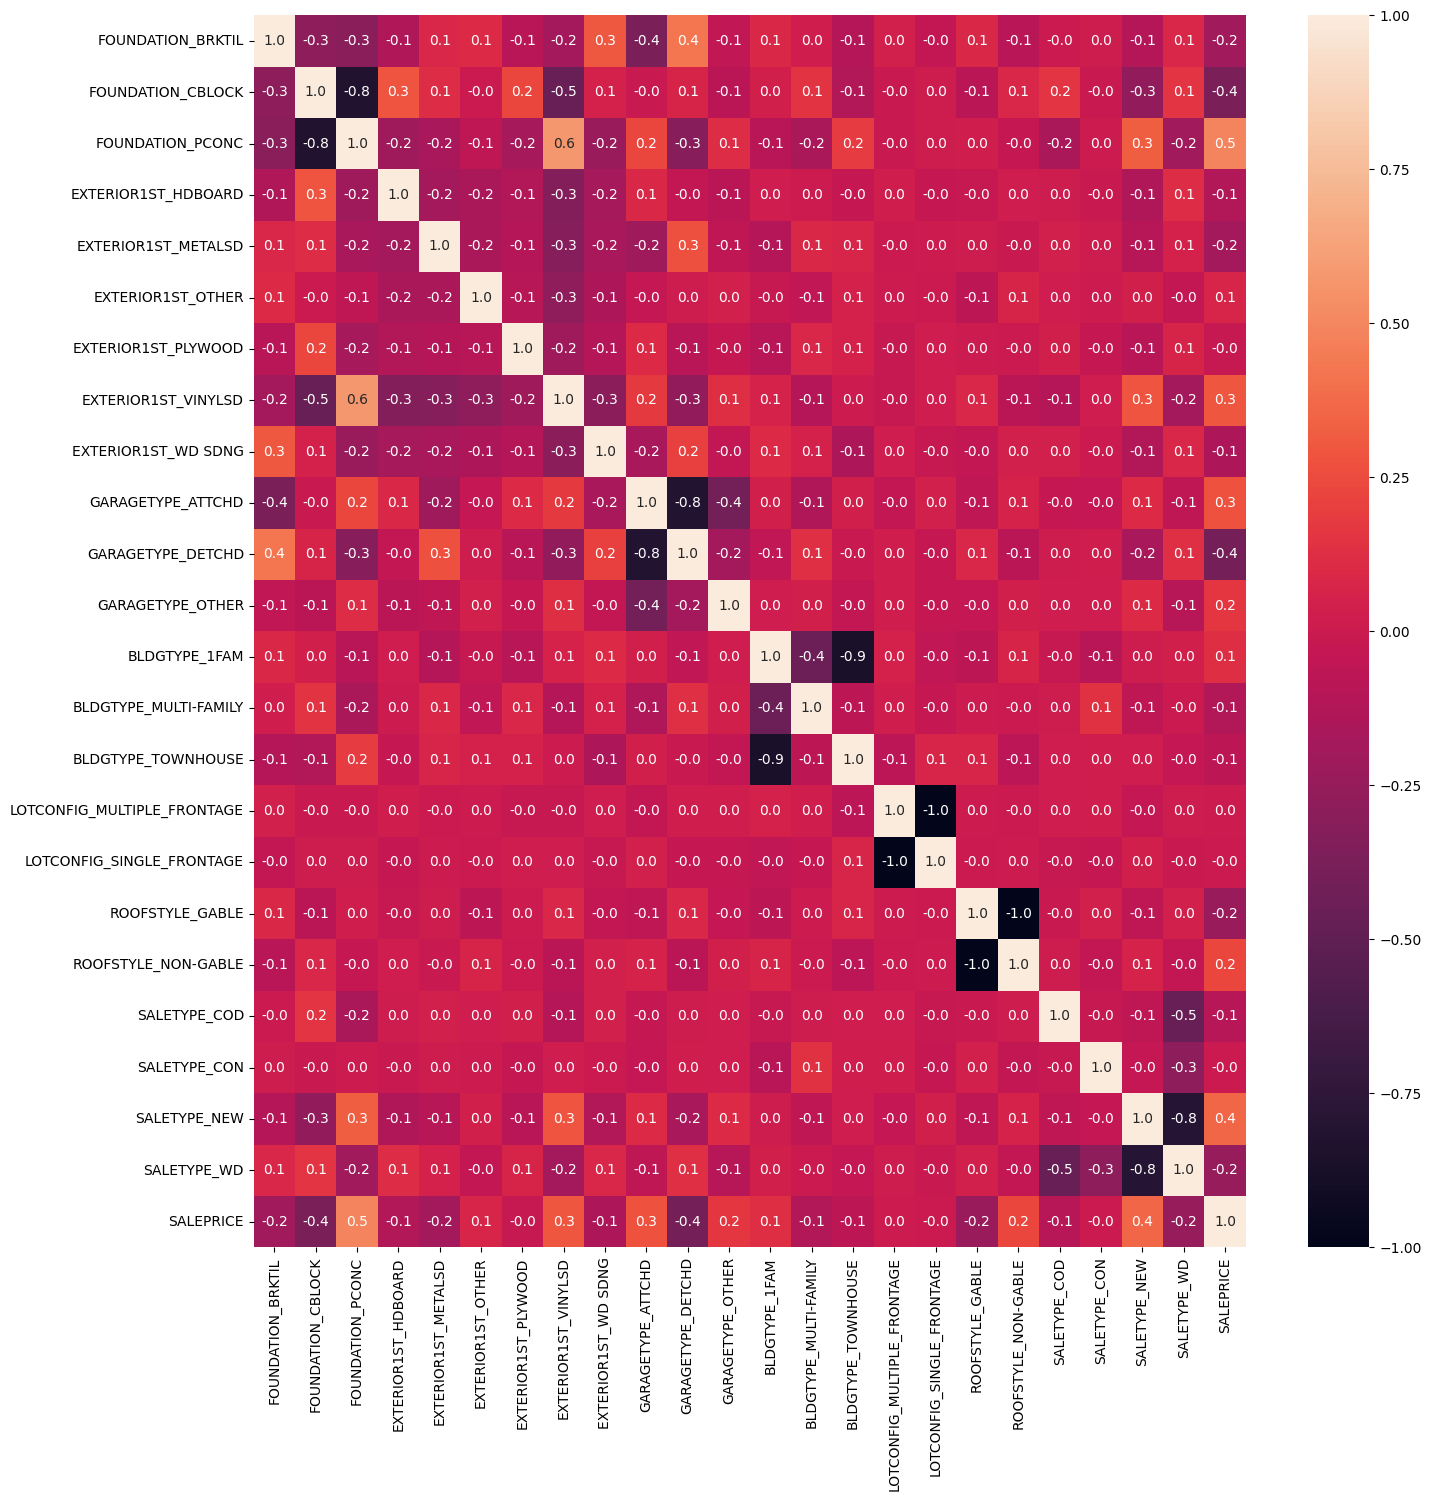

In [459]:
plt.figure(figsize=(16, 16))
sns.heatmap(df_clean_qual_nom_dummy.corr(), annot=True, fmt=".1f")

## Treatment of Quantitative Discrete variables

## Treatment of Quantitative Continuous variables

### Outlier Treatment

In [457]:
# SKEWNESS ANALYSIS

df_clean_cont = df_clean_qual_nom.copy()

skewness = {}

for col in columns_quan_cont:
    skewness[col] = df_clean_cont[col].skew()

df_skewness = pd.DataFrame.from_dict(skewness, orient="index", columns=["SKEWNESS"])
df_skewness = df_skewness.reset_index()
df_skewness = df_skewness.rename(columns={"index": "CATEGORY"})

df_skewness.sort_values(by=["SKEWNESS"], ascending=False).reset_index(drop=True)

columns_to_log = df_skewness[
    (df_skewness["SKEWNESS"] > 1) | (df_skewness["SKEWNESS"] < -1)
]
columns_normal = df_skewness[
    (df_skewness["SKEWNESS"] < 1) & (df_skewness["SKEWNESS"] > -1)
]


# LOG TRANSFORMATION
df_log_analysis = df[columns_quan_cont].copy()
for col in columns_to_log["CATEGORY"]:
    df_log_analysis[col + "_LOG"] = np.log1p(df_log_analysis[col])


# CLEANING OF OUTLIERS
prop_to_delete = 0.02

candidates = [
    (0.25, 0.75),
    (0.20, 0.80),
    (0.15, 0.85),
    (0.10, 0.90),
    (0.05, 0.95),
    (0.02, 0.98),
    (0.01, 0.99),
]

for col in columns_to_log["CATEGORY"]:
    n_total = len(df_clean_cont[col])

    for q1_pct, q3_pct in candidates:
        q1 = df_clean_cont[col].quantile(q1_pct)
        q3 = df_clean_cont[col].quantile(q3_pct)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        mask = (df_clean_cont[col] >= lower) & (df_clean_cont[col] <= upper)
        pct_removed = 1 - mask.sum() / n_total

        if pct_removed < prop_to_delete:
            break

    # print(f"{col}: quantiles=({q1_pct}, {q3_pct}) | bounds=[{lower:.2f}, {upper:.2f}] | removed={pct_removed:.1%}")
    df_clean_cont = df_clean_cont[mask]

for col in columns_normal["CATEGORY"]:
    n_total = len(df_clean_cont[col])

    for q1_pct, q3_pct in candidates:
        q1 = df_clean_cont[col].quantile(q1_pct)
        q3 = df_clean_cont[col].quantile(q3_pct)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        mask = (df_clean_cont[col] >= lower) & (df_clean_cont[col] <= upper)
        pct_removed = 1 - mask.sum() / n_total

        if pct_removed < prop_to_delete:
            break

    # print(f"{col}: quantiles=({q1_pct}, {q3_pct}) | bounds=[{lower:.2f}, {upper:.2f}] | removed={pct_removed:.1%}")
    df_clean_cont = df_clean_cont[mask]

print(
    100 - round(df_clean_cont.shape[0] / df_raw.shape[0], 2) * 100,
    "% of data was deleted",
)


26.0 % of data was deleted


Observation: As shown above, the discrete variables contain fewer outliers than the continuous variables. Given this lower frequency, the outliers of this variable type were retained.

In [458]:
'''
df_clean_disc = df_clean_cont.copy()

for col in columns_quan_disc:
    fig = px.box(df_clean_disc, y=col)
    fig.show()
'''

'\ndf_clean_disc = df_clean_cont.copy()\n\nfor col in columns_quan_disc:\n    fig = px.box(df_clean_disc, y=col)\n    fig.show()\n'